# Análise de Carros Usados vs Tabela FIPE

**Projeto Final — Análise de Texto de Fontes Desestruturadas e Web** · Insper · 2026

Trabalho desenvolvido por:
- **Pedro Zimmermann**
- **Beatriz Cia**
- **Laura Magro**
- **Maria Eduarda Marques**

Notebook **autocontido**: todas as funções estão inline. Lê CSVs gerados pela coleta (em `data/`), mas o código de scraping/matching/LLM/modelo está reproduzido nas células — basta descomentar as células marcadas para regenerar os dados do zero.

## ⚠️ Pré-requisitos para reproduzir este notebook

Este notebook é **autocontido**: todo o código de coleta, parsing, matching, LLM e modelagem está inline.

**Para rodar o notebook do início ao fim**, você precisa:

1. **Pasta `data/` no mesmo diretório do notebook**, com os CSVs já gerados:
   - `data/icarros.csv` (~700 KB) — 1469 anúncios SP com matching FIPE aplicado
   - `data/llm_features.csv` (~30 KB) — 544 anúncios com features extraídas via LLM
   - `data/detalhes_atributos.csv` (~1 MB) — atributos da página de detalhe (blindado, etc.)
   - `data/fipe_cache/` (~200 KB) — cache JSON da API FIPE (opcional, só pra re-executar matching)

2. **Bibliotecas Python**: `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`, `requests`, `beautifulsoup4`, `lxml`, `tqdm`. Instale com:
   ```bash
   pip install pandas numpy scikit-learn matplotlib seaborn requests beautifulsoup4 lxml tqdm
   ```

3. **(Opcional) Ollama rodando** com `llama3.1:8b` — só se quiser regenerar features LLM do zero. Sem isso, o notebook lê do CSV pronto.

**Para coletar dados do zero** (sem usar CSVs prontos): descomente a célula "Re-coleta do zero" na seção 4. Aviso: a coleta completa demora ~2h (1469 páginas de listagem + 1469 páginas de detalhe + 544 chamadas Ollama).

## TL;DR — Resumo executivo

**O que fizemos.** Coletamos 1469 anúncios de seminovos no iCarros (SP, 5 modelos: Onix, HB20, Polo, T-Cross, Kwid), cruzamos com a Tabela FIPE via matching por tokens, enriquecemos com LLM local (Ollama llama3.1:8b) sobre descrições livres dos vendedores, e treinamos um Gradient Boosting Regressor pra prever o desvio percentual entre preço anunciado e FIPE.

**Três achados principais**:

1. **Blindagem é o single best preditor depois de idade/km.** Apenas 0.27% dos anúncios são blindados, mas explicam 3 dos 4 maiores desvios positivos da FIPE (+40% a +47% acima do valor de tabela). `blindado` aparece como 2ª feature mais importante do modelo.

2. **Modelo final tem RMSE ~5%, R² entre 0.27 e 0.32** (estável via CV 5-fold). Bate o baseline RandomForest. O ganho veio de atributos estruturados extraídos da `<meta description>` da página de detalhe (blindado, sensor estacionamento, teto solar, número total de itens).

3. **Outliers abaixo da FIPE não são bug** — ~90% têm matching FIPE correto; o desvio reflete mercado real (Onix Turbo LT 2025 sendo vendido -14% em vários anúncios, padrão competitivo de revenda) ou km alto (Polo 2012 com 170k km).

## 1. Introdução

O mercado brasileiro de seminovos movimenta mais de 10 milhões de transações por ano, e a Tabela FIPE é a referência de valor adotada por bancos, seguradoras e consumidores. Mesmo assim, anúncios reais raramente batem o valor FIPE — desviam para cima (modelos premium, baixa quilometragem, lojistas) ou para baixo (vendas urgentes, alto km, histórico ruim).

Este projeto pergunta quais fatores explicam esse desvio, para 5 modelos populares no segmento de entrada/intermediário: Chevrolet Onix, Hyundai HB20, Volkswagen Polo, Volkswagen T-Cross, Renault Kwid.

O exercício é simultaneamente prático (precificação) e metodológico — mistura dados estruturados de classificados (preço, ano, km, opcionais), dados não-estruturados (descrição livre do vendedor) e referência externa (Tabela FIPE pública).

## 2. Pergunta de pesquisa

> Quais fatores fazem um carro usado ser anunciado **acima** ou **abaixo** da Tabela FIPE, e é possível prever esse desvio a partir das características e descrição do anúncio?

**Variável-alvo**:

$$\text{desvio\_fipe} = \frac{\text{preço anunciado} - \text{preço FIPE}}{\text{preço FIPE}}$$

`desvio_fipe = 0.05` → 5% acima da FIPE. `-0.10` → 10% abaixo. Usar razão relativa controla o efeito de preços absolutos diferentes entre modelos (Kwid ~R$ 55k vs T-Cross ~R$ 110k).

## 3. Metodologia

Pipeline em 4 etapas:

1. **Coleta** — iCarros (HTML SSR) + página de detalhe + API FIPE (Parallelum).
2. **RegEx** — extrai km, anos, opcionais de texto livre + tokenização simétrica do nome FIPE pra fazer matching.
3. **LLM local Ollama** (`llama3.1:8b`, temp=0) — extrai 6 campos estruturados da descrição livre do vendedor.
4. **Gradient Boosting Regressor** (sklearn) — prevê `desvio_fipe` com features estruturadas + features extraídas via LLM.

**Nota sobre coleta**: tentamos a Webmotors primeiro, mas tem anti-bot PerimeterX (captcha 'Press & Hold' não-resolvível headless). Migramos pro iCarros, que é SSR e responde 200 com `requests` + BeautifulSoup.

## Setup

Imports e configurações.

In [1]:
import json, re, time, unicodedata, math, random
from pathlib import Path
from typing import Any, Optional
from statistics import median

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')

DATA = Path('data')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## 4. Coleta de dados

### 4.1 iCarros — listagem

Cada card de anúncio no iCarros é um `<li class='offer-card'>` com um `onclick` na imagem carregando um JSON-like de Google Analytics 4. **Não é JSON válido** (chaves sem aspas, aspas simples, vírgulas finais), então usamos **RegEx por campo** — 9 padrões independentes.

A função `parse_card` abaixo extrai 13 campos do HTML do card. A coleta completa percorre 5 modelos × até 35 páginas = ~1500 anúncios.

In [2]:
# ===== Funções de coleta (iCarros) — inline para autocontensão =====
# Coleta real fica comentada nas células abaixo; o notebook lê do CSV.

ICARROS_BASE = "https://www.icarros.com.br/comprar"
DOMAIN = "https://www.icarros.com.br"
USER_AGENT = ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
              "(KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36")

MODELS = [
    ("chevrolet",  "onix"),
    ("hyundai",    "hb20"),
    ("volkswagen", "polo"),
    ("volkswagen", "t-cross"),
    ("renault",    "kwid"),
]

# Regex pros campos uteis do onclick
ONCLICK_FIELDS = {
    "brand":      re.compile(r"item_brand:\s*'([^']+)'"),
    "name":       re.compile(r"item_name:\s*'([^']+)'"),
    "variant":    re.compile(r"item_variant:\s*'([^']+)'"),
    "price":      re.compile(r"price:\s*(\d+)"),
    "uf":         re.compile(r"item_category3:\s*'([^']*)'"),
    "cidade":     re.compile(r"item_category4:\s*'([^']*)'"),
    "tipo_anun":  re.compile(r"item_category5:\s*'([^']*)'"),
    "cambio":     re.compile(r"tipo_cambio:\s*'([^']*)'"),
    "cor":        re.compile(r"cor:\s*'([^']*)'"),
}

UNICODE_ESC = re.compile(r"\\u([0-9a-fA-F]{4})")
def _decode_unicode(s: str) -> str:
    """'Jo\\u00E3o' -> 'João'"""
    return UNICODE_ESC.sub(lambda m: chr(int(m.group(1), 16)), s)

print(f"5 modelos × ~35 paginas × 20 cards = ~3500 candidatos brutos")
print(f"Apos filtro SP + dedup: 1469 anuncios (ver data/icarros.csv)")

5 modelos × ~35 paginas × 20 cards = ~3500 candidatos brutos
Apos filtro SP + dedup: 1469 anuncios (ver data/icarros.csv)


In [3]:
# ===== Funções de coleta iCarros (não executadas — código de referência) =====

def parse_card(li):
    """Achata um <li class='offer-card'> em dict."""
    try:
        ad_id = int(li.get('data-anuncioid'))
        a = li.select_one('a.offer-card__image-container')
        if not a: return None
        url = a['href']
        url = (DOMAIN + url if url.startswith('/') else url).split('?')[0]
        img = li.find('img')
        onclick = (img.get('onclick') or '') if img else ''
        title_img = (img.get('title') or img.get('alt') or '') if img else ''
        fields = {}
        for k, pat in ONCLICK_FIELDS.items():
            m = pat.search(onclick)
            fields[k] = _decode_unicode(m.group(1)) if m else None
        if fields['price'] is None: return None
        ano = int(fields['variant']) if fields['variant'] else 0
        km = None
        info = li.select_one('.info-container__car-info')
        if info:
            m = re.search(r'([\d.]+)\s*km', info.get_text(' '), re.I)
            if m: km = int(m.group(1).replace('.', ''))
        return {
            'id_anuncio': ad_id, 'url_anuncio': url,
            'marca': fields['brand'] or '', 'modelo': fields['name'] or '',
            'versao': title_img, 'titulo': title_img,
            'ano_modelo': ano, 'preco': float(fields['price']),
            'km': km, 'uf': fields['uf'] or '', 'cidade': fields['cidade'] or '',
            'cor': fields['cor'] or '', 'transmissao': fields['cambio'] or '',
            'tipo_anunciante': fields['tipo_anun'] or '',
        }
    except (KeyError, TypeError, ValueError, AttributeError):
        return None


def _session():
    import requests
    s = requests.Session()
    s.headers.update({'User-Agent': USER_AGENT, 'Accept-Language': 'pt-BR'})
    return s


def scrape_modelo(marca, modelo, max_pages=35, sess=None):
    """Coleta até `max_pages` da listagem. Sleep 3s entre páginas."""
    import requests
    from bs4 import BeautifulSoup
    from tqdm.auto import tqdm
    sess = sess or _session()
    rows, seen = [], set()
    for page in tqdm(range(1, max_pages + 1), desc=f'{marca}/{modelo}'):
        url = f'{ICARROS_BASE}/{marca}/{modelo}' + (f'?pag={page}' if page > 1 else '')
        try:
            r = sess.get(url, timeout=20)
            if r.status_code != 200: break
        except requests.RequestException:
            break
        soup = BeautifulSoup(r.text, 'lxml')
        cards = soup.select('li.offer-card')
        if not cards: break
        matched = 0
        for li in cards:
            parsed = parse_card(li)
            if not parsed: continue
            if marca.lower() not in parsed['marca'].lower(): continue
            if modelo.lower().replace('-','') not in parsed['modelo'].lower().replace('-',''): continue
            if parsed['id_anuncio'] in seen: continue
            seen.add(parsed['id_anuncio'])
            parsed['modelo_alvo'] = modelo
            parsed['data_coleta'] = pd.Timestamp.now().isoformat()
            rows.append(parsed)
            matched += 1
        if matched == 0 and page > 2: break
        time.sleep(3)
    return pd.DataFrame(rows)


def scrape_all(output_csv=Path('data/icarros.csv'), max_pages=35, so_sp=True):
    """Coleta os 5 modelos. Filtra SP se so_sp=True."""
    sess = _session()
    dfs = []
    for marca, modelo in MODELS:
        dfs.append(scrape_modelo(marca, modelo, max_pages=max_pages, sess=sess))
    full = pd.concat(dfs, ignore_index=True).drop_duplicates('id_anuncio')
    if so_sp:
        full = full[full['uf'] == 'SP'].reset_index(drop=True)
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    full.to_csv(output_csv, index=False, encoding='utf-8')
    return full

# Pra coletar do zero (~12 min), descomente:
# df_novo = scrape_all(max_pages=35, so_sp=True)

### 4.2 Carregando o dataset já coletado

A coleta levou ~12 minutos. O CSV está em `data/icarros.csv`. Para regenerar do zero, basta descomentar a célula a seguir.

In [4]:
# Para regenerar a coleta do zero (~12 min), descomente a linha abaixo.
# As funções parse_card / scrape_modelo / scrape_all estão definidas
# na célula anterior (tudo inline, sem dependência de arquivos externos).
# scrape_all(max_pages=35, so_sp=True)  ->  (re)gera data/icarros.csv

# Leitura do CSV já coletado:
df = pd.read_csv(DATA / 'icarros.csv')
print(f'Total: {len(df)} anúncios (filtro SP)')
print(f'\nPor modelo:')
print(df['modelo_alvo'].value_counts())
print(f'\nAmostra:')
df[['id_anuncio','marca','modelo','versao','ano_modelo','km','preco','cidade']].head()

Total: 1469 anúncios (filtro SP)

Por modelo:
modelo_alvo
hb20       321
polo       298
onix       292
kwid       290
t-cross    268
Name: count, dtype: int64

Amostra:


,id_anuncio,marca,modelo,versao,ano_modelo,km,preco,cidade
0,57486159,Chevrolet,Onix,1.0 LT manual,2025,46242.0,74490.0,São Paulo
1,57481527,Chevrolet,Onix,1.0 LT manual,2025,41293.0,74490.0,São Paulo
2,57484067,Chevrolet,Onix,1.0 manual,2023,51547.0,67890.0,Mauá
3,57484646,Chevrolet,Onix,1.0 Turbo LTZ (Aut) automático,2025,32624.0,98490.0,Araras
4,57378926,Chevrolet,Onix,1.0 Turbo LT manual,2025,48017.0,72490.0,Suzano


### 4.3 FIPE — matching anúncio ↔ versão

A API pública [Parallelum FIPE](https://parallelum.com.br/fipe/api/v1) fornece marcas → modelos → anos → preço. Para cada modelo-alvo ('Onix') existem **dezenas de versões FIPE** ('ONIX HATCH LT 1.0', 'ONIX SEDAN Plus PREM. 1.0', etc.).

O **matching é o ponto crítico**: o título do anúncio é compacto ('1.0 LT manual'), o nome FIPE é verboso ('ONIX HATCH LT 1.0 12V Flex 5p Mec.'). Tokenizamos os dois lados com a **mesma função** (mesma normalização, mesmo stop-list) e pegamos a versão FIPE do mesmo ano com maior interseção.

**3 buckets de confiança**:
- `exato`: score ≥ 3 tokens em comum
- `fuzzy`: score = 2 tokens
- `fallback_p25`: nenhuma versão satisfaz → P25 dos preços do ano (versão base é mais provável que mediana)

A **escolha de P25 em vez de mediana** no fallback é importante: corrige viés sistemático de mediana puxando pra cima quando o anúncio é versão simples.

In [5]:
# ===== Tokenizacao FIPE — usada nos DOIS lados (anuncio e FIPE) =====

STOP_TOKENS = {
    "chevrolet", "gm", "hyundai", "volkswagen", "vw", "renault",
    "onix", "hb20", "polo", "tcross", "kwid",
    "flex", "etanol", "12v", "5p", "4p", "mpi", "gdi", "8v", "sce",
    "r7i", "r7g", "r7m", "rfc", "rfd", "rfe", "spe", "vht",
    "200", "250", "mi", "tot", "rio", "rock", "in", "cross",
}

CANON = [
    (re.compile(r"\baut\.?\b"),   "automatico"),
    (re.compile(r"\bmec\.?\b"),   "manual"),
    (re.compile(r"\bprem\.?\b"),  "premier"),
    (re.compile(r"\bhig\.?\b"),   "highline"),
    (re.compile(r"\btb\b"),       "turbo"),
]

def _norm(text):
    t = unicodedata.normalize("NFKD", str(text or "")).encode("ascii", "ignore").decode("ascii").lower()
    for pat, repl in CANON:
        t = pat.sub(repl, t)
    return t

def tokenize(text):
    """Mesma tokenizacao para anuncio e FIPE — vocabulario simetrico."""
    t = _norm(text)
    t = re.sub(r"[^a-z0-9.]+", " ", t)
    return {
        w.strip(".") for w in t.split()
        if len(w) >= 2 and w.strip(".") not in STOP_TOKENS
        and not re.fullmatch(r"\d+v?p?|\d{4}", w)
    }

# Sanity check
exemplo_anuncio = "Chevrolet Onix Onix 1.0 Turbo LTZ automatico"
exemplo_fipe = "ONIX HATCH LTZ 1.0 12V TB Flex 5p Aut."
print(f"tokenize('{exemplo_anuncio}'):")
print(f"  -> {sorted(tokenize(exemplo_anuncio))}")
print(f"\ntokenize('{exemplo_fipe}'):")
print(f"  -> {sorted(tokenize(exemplo_fipe))}")
print(f"\nInterseccao: {sorted(tokenize(exemplo_anuncio) & tokenize(exemplo_fipe))}")

tokenize('Chevrolet Onix Onix 1.0 Turbo LTZ automatico'):
  -> ['1.0', 'automatico', 'ltz', 'turbo']

tokenize('ONIX HATCH LTZ 1.0 12V TB Flex 5p Aut.'):
  -> ['1.0', 'automatico', 'hatch', 'ltz', 'turbo']

Interseccao: ['1.0', 'automatico', 'ltz', 'turbo']


In [6]:
# ===== match_anuncio: heuristica de matching com 3 buckets =====
# (Funcao completa, autocontida. FipeClient e build_index ficam em arquivo
# separado por brevidade; o CSV já tem o resultado.)

def match_anuncio(row, fipe_index):
    """Devolve dict com fipe_codigo, fipe_nome, fipe_preco, fipe_match_score, fipe_bucket.

    fipe_index eh um dict {modelo_alvo: [{nome, ano, preco, codigo_fipe}, ...]}
    """
    modelo = str(row['modelo_alvo']).lower()
    ano = int(row['ano_modelo'])
    candidatas = [e for e in fipe_index.get(modelo, []) if e['ano'] == ano]
    if not candidatas:
        candidatas = [e for e in fipe_index.get(modelo, []) if e['ano'] == ano - 1]
    if not candidatas:
        return {"fipe_codigo": None, "fipe_nome": None, "fipe_preco": None,
                "fipe_match_score": 0, "fipe_bucket": "sem_match"}

    tokens_anuncio = tokenize(f"{row.get('titulo','')} {row.get('versao','')}")
    cambio_anun = _norm(row.get('transmissao', ''))
    tem_cambio = 'auto' in cambio_anun or 'manual' in cambio_anun or 'mec' in cambio_anun

    scored = []
    for e in candidatas:
        tokens_fipe = tokenize(e['nome'])
        if tem_cambio:
            fipe_auto = bool(tokens_fipe & {'automatico','cvt'})
            fipe_manual = bool(tokens_fipe & {'manual'})
            anun_auto = 'auto' in cambio_anun
            if anun_auto and fipe_manual and not fipe_auto:
                continue
            if not anun_auto and fipe_auto and not fipe_manual:
                continue
        scored.append((len(tokens_anuncio & tokens_fipe), e))

    if not scored:
        precos = sorted(e['preco'] for e in candidatas)
        p25 = precos[max(0, len(precos)//4)]
        return {"fipe_codigo": None, "fipe_nome": f"p25_ano (n={len(candidatas)})",
                "fipe_preco": p25, "fipe_match_score": 0, "fipe_bucket": "fallback_p25"}

    scored.sort(key=lambda t: t[0], reverse=True)
    top_score, top = scored[0]
    if top_score >= 3:
        return {"fipe_codigo": top['codigo_fipe'], "fipe_nome": top['nome'],
                "fipe_preco": top['preco'], "fipe_match_score": top_score,
                "fipe_bucket": "exato"}
    if top_score >= 2:
        return {"fipe_codigo": top['codigo_fipe'], "fipe_nome": top['nome'],
                "fipe_preco": top['preco'], "fipe_match_score": top_score,
                "fipe_bucket": "fuzzy"}
    precos = sorted(e['preco'] for _, e in scored)
    p25 = precos[max(0, len(precos)//4)]
    return {"fipe_codigo": None, "fipe_nome": f"p25_filtrada (n={len(scored)})",
            "fipe_preco": p25, "fipe_match_score": top_score, "fipe_bucket": "fallback_p25"}

print("match_anuncio definida. O CSV ja contem as colunas fipe_* aplicadas nos 1469.")

match_anuncio definida. O CSV ja contem as colunas fipe_* aplicadas nos 1469.


In [7]:
# ===== FipeClient + build_index + aplicar_matching (codigo de referencia) =====

MARCAS_LABELS = {'onix':'Chevrolet','hb20':'Hyundai','polo':'Volkswagen',
                 't-cross':'Volkswagen','kwid':'Renault'}
MODELOS_LABELS = {'onix':'Onix','hb20':'HB20','polo':'Polo',
                  't-cross':'T-Cross','kwid':'Kwid'}
FIPE_BASE_URL = 'https://parallelum.com.br/fipe/api/v1/carros'


class FipeClient:
    """GET com cache em disco. Sleep entre requests pra nao tomar 429."""

    def __init__(self, cache_dir=Path('data/fipe_cache')):
        self.cache_dir = cache_dir
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        import requests
        self.s = requests.Session()
        self.s.headers['Accept'] = 'application/json'

    def _get(self, path, cache_key):
        if cache_key.exists():
            return json.loads(cache_key.read_text(encoding='utf-8'))
        import requests
        url = f'{FIPE_BASE_URL}/{path}'
        r = self.s.get(url, timeout=20)
        if r.status_code == 429:
            raise RuntimeError('HTTP 429 — rate-limit Parallelum. Aguarde 30-60 min.')
        r.raise_for_status()
        data = r.json()
        cache_key.parent.mkdir(parents=True, exist_ok=True)
        cache_key.write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding='utf-8')
        time.sleep(random.uniform(1.5, 2.5))
        return data

    def marcas(self):
        return self._get('marcas', self.cache_dir / 'marcas.json')

    def modelos(self, brand_code):
        return self._get(f'marcas/{brand_code}/modelos',
                         self.cache_dir / f'marca_{brand_code}' / 'modelos.json')

    def anos(self, brand_code, model_code):
        return self._get(f'marcas/{brand_code}/modelos/{model_code}/anos',
                         self.cache_dir / f'marca_{brand_code}' / f'modelo_{model_code}' / 'anos.json')

    def preco(self, brand_code, model_code, year_code):
        return self._get(f'marcas/{brand_code}/modelos/{model_code}/anos/{year_code}',
                         self.cache_dir / f'marca_{brand_code}' / f'modelo_{model_code}' / f'ano_{year_code}.json')

    def find_brand(self, name):
        target = name.lower()
        for b in self.marcas():
            if target in b['nome'].lower():
                return b['codigo']
        raise LookupError(f'marca {name!r} nao encontrada')

    def find_models(self, brand_code, name):
        target = name.lower().replace('-', '')
        return [m for m in self.modelos(brand_code)['modelos']
                if target in m['nome'].lower().replace('-', '')]


def build_index(client=None, min_year=2007, max_year=2026):
    """Constroi {modelo_alvo: [{nome, ano, preco, codigo_fipe}, ...]}."""
    client = client or FipeClient()
    index = {}
    for slug, modelo_label in MODELOS_LABELS.items():
        brand_code = client.find_brand(MARCAS_LABELS[slug])
        models = client.find_models(brand_code, modelo_label)
        entries = []
        for m in models:
            try: anos = client.anos(brand_code, m['codigo'])
            except Exception: continue
            for a in anos:
                ym = re.search(r'\b(19|20)\d{2}\b', a['nome'])
                if not ym: continue
                ano = int(ym.group())
                if not (min_year <= ano <= max_year): continue
                try: p = client.preco(brand_code, m['codigo'], a['codigo'])
                except Exception: continue
                valor = float(re.sub(r'[^\d,]', '', p.get('Valor','')).replace(',', '.'))
                entries.append({
                    'codigo_fipe': p.get('CodigoFipe',''),
                    'nome': p.get('Modelo', m['nome']),
                    'ano': ano, 'preco': valor, 'modelo_alvo': slug,
                })
        index[slug] = entries
    return index


def aplicar_matching(df, fipe_index):
    """Adiciona colunas fipe_* + desvio_fipe ao df."""
    out_rows = [match_anuncio(r.to_dict(), fipe_index) for _, r in df.iterrows()]
    fipe_df = pd.DataFrame(out_rows, index=df.index)
    combined = pd.concat([df.reset_index(drop=True), fipe_df.reset_index(drop=True)], axis=1)
    combined['desvio_fipe'] = (combined['preco'] - combined['fipe_preco']) / combined['fipe_preco']
    return combined

# Pra re-rodar matching do zero (~5min):
# fipe_index = build_index(FipeClient())
# df = aplicar_matching(df_sem_fipe, fipe_index)

In [8]:
# Distribuicao dos buckets de matching (no CSV ja aplicado)
print('Distribuicao por bucket:')
print(df['fipe_bucket'].value_counts())
print(f'\nDesvio FIPE mediana por bucket:')
print((df.groupby('fipe_bucket')['desvio_fipe'].median() * 100).round(2).astype(str) + ' %')
print(f'\ndesvio_fipe stats gerais:')
print(df['desvio_fipe'].describe().round(4))

Distribuicao por bucket:
fipe_bucket
exato           1250
fuzzy            162
fallback_p25      57
Name: count, dtype: int64

Desvio FIPE mediana por bucket:
fipe_bucket
exato           3.64 %
fallback_p25    2.26 %
fuzzy           3.17 %
Name: desvio_fipe, dtype: object

desvio_fipe stats gerais:
count    1469.0000
mean        0.0384
std         0.0603
min        -0.2160
25%         0.0105
50%         0.0343
75%         0.0631
max         0.4667
Name: desvio_fipe, dtype: float64


### 4.4 Página de detalhe — atributos extras

Visitamos a página de detalhe dos 1469 anúncios para extrair:
- **blindado** (bool) — palavra 'blindad' na `<meta description>` (NÃO em `<meta keywords>`, que tem lixo SEO genérico)
- 5 atributos: ar-condicionado, sensor estacionamento, multimídia, teto solar, câmera ré
- **atributos_extra_n** — contagem de itens listados (proxy de "anúncio rico")
- **descricao_livre** — texto livre escrito pelo vendedor (~36% têm)

**Pegadinha resolvida**: a primeira passagem deu 35.3% blindados (falso positivo do `<meta keywords>` que tem "blindado, gnv" em todo anúncio como SEO genérico). Correção: usar apenas `<meta description>` (específica por anúncio).

In [9]:
# ===== Função parse_detalhe inline (parsea HTML de detalhe) =====

ATTR_PATTERNS = {
    "blindado":            re.compile(r"\bblindad", re.IGNORECASE),
    "has_ar_meta":         re.compile(r"\bar[\s-]*condicionad", re.IGNORECASE),
    "has_sensor_meta":     re.compile(r"\bsensor (?:de )?(?:estacionament|r[eé])", re.IGNORECASE),
    "has_multimidia_meta": re.compile(r"\b(multim[ií]dia|bluetooth|carplay|android auto)", re.IGNORECASE),
    "has_teto_solar_meta": re.compile(r"\bteto solar", re.IGNORECASE),
    "has_camera_re_meta":  re.compile(r"\bc[âa]mera (?:de )?r[eé]", re.IGNORECASE),
}

def parse_detalhe(html):
    """Atributos + descricao livre. Usa SO meta description (sem meta keywords SEO)."""
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(html, 'lxml')
    md_tag = soup.find('meta', attrs={'name': 'description'})
    desc_text = (md_tag.get('content') if md_tag else '') or ''
    # Extração da descrição livre + regex de atributos (código completo abaixo).
    out = {}
    for s in soup(['script','style','noscript']): s.decompose()
    BLOCK = {'menu','modal','footer','breadcrumb','hidemessage','tooltip','consent','opcionais','detalhes-anuncio'}
    best = ""
    best_kw = 0
    DESC_KW = ('cautelar','troca','dono','unico','único','garantia','financia','revisa','vistor','cliente','vendedor','conservad','impecavel','impecável','novissimo','perfeit')
    for p in soup.find_all('p'):
        text = re.sub(r'\s+', ' ', p.get_text(' ', strip=True))
        if not (100 <= len(text) <= 3000): continue
        cur = p.parent
        blocked = False
        for _ in range(3):
            if cur is None: break
            cls = ' '.join(cur.get('class') or []).lower()
            if any(b in cls for b in BLOCK):
                blocked = True; break
            cur = cur.parent
        if blocked: continue
        segs = [s.strip() for s in text.split(',') if s.strip()]
        if len(segs) >= 5 and (sum(len(s) for s in segs)/len(segs)) < 30: continue
        kw = sum(1 for k in DESC_KW if k in text.lower())
        if kw >= 2 and kw > best_kw:
            best, best_kw = text, kw
    out['descricao_livre'] = best
    out['descricao_livre_len'] = len(best)
    combined = f'{desc_text} | {best}'
    for name, pat in ATTR_PATTERNS.items():
        out[name] = bool(pat.search(combined))
    parts = [p.strip() for p in desc_text.split(',') if p.strip()] if desc_text else []
    out['atributos_extra_n'] = max(0, len(parts) - 7)
    return out

# Carrega tabela de detalhes ja coletada
det = pd.read_csv(DATA / 'detalhes_atributos.csv')
print(f'detalhes_atributos.csv: {len(det)} anuncios')
print(f'\n% por atributo:')
for c in ['blindado','has_ar_meta','has_sensor_meta','has_multimidia_meta','has_teto_solar_meta','has_camera_re_meta']:
    print(f'  {c:24s} {det[c].astype(bool).mean()*100:>5.2f}%')
print(f'  atributos_extra_n medio: {det["atributos_extra_n"].mean():.1f}')
print(f'  com descricao livre: {(det["descricao_livre_len"]>0).mean()*100:.1f}%')

# Merge no df principal
df = df.merge(det.drop(columns=['_falhou'], errors='ignore'), on='id_anuncio', how='left')
for c in ['blindado','has_ar_meta','has_sensor_meta','has_multimidia_meta','has_teto_solar_meta','has_camera_re_meta']:
    df[c] = df[c].fillna(False).astype(bool)
df['atributos_extra_n'] = df['atributos_extra_n'].fillna(0).astype(int)
df['descricao_livre_len'] = df['descricao_livre_len'].fillna(0).astype(int)
print(f'\nMerge OK: df agora tem {df.shape[1]} colunas')

detalhes_atributos.csv: 1469 anuncios

% por atributo:
  blindado                  0.27%
  has_ar_meta              54.94%
  has_sensor_meta          25.05%
  has_multimidia_meta      22.19%
  has_teto_solar_meta       1.97%
  has_camera_re_meta        1.36%
  atributos_extra_n medio: 4.8
  com descricao livre: 36.1%

Merge OK: df agora tem 37 colunas


In [10]:
# ===== Coleta de descricoes livres + download HTML detalhe =====

def baixar_detalhe(id_anuncio, url, sess, cache_dir=Path('data/icarros_details')):
    """Baixa HTML da pagina de detalhe. Cacheia em disco. Retorna (html, cache_hit)."""
    import requests
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache = cache_dir / f'{id_anuncio}.html'
    if cache.exists():
        return cache.read_text(encoding='utf-8', errors='ignore'), True
    try:
        r = sess.get(url, timeout=20)
        if r.status_code != 200: return None, False
    except requests.RequestException:
        return None, False
    cache.write_text(r.text, encoding='utf-8')
    return r.text, False


def enriquecer_com_detalhes(df, output_csv=Path('data/detalhes_atributos.csv'), sleep_sec=3.0):
    """Visita detalhe de cada anuncio, extrai atributos + descricao livre.

    Idempotente: cacheia HTML em data/icarros_details/ e CSV em data/detalhes_atributos.csv.
    Re-execucoes pulam IDs ja processados.
    """
    from tqdm.auto import tqdm
    ja_feitos = set()
    if output_csv.exists():
        ja_feitos = set(pd.read_csv(output_csv)['id_anuncio'].astype(int))
    pendentes = df[~df['id_anuncio'].isin(ja_feitos)]
    if pendentes.empty:
        return pd.read_csv(output_csv)

    sess = _session()
    buffer = []
    for _, row in tqdm(pendentes.iterrows(), total=len(pendentes), desc='detalhes'):
        aid = int(row['id_anuncio'])
        html, cache_hit = baixar_detalhe(aid, str(row['url_anuncio']), sess)
        if not html:
            entry = {'id_anuncio': aid, '_falhou': True,
                     'blindado': False, 'has_ar_meta': False, 'has_sensor_meta': False,
                     'has_multimidia_meta': False, 'has_teto_solar_meta': False,
                     'has_camera_re_meta': False, 'atributos_extra_n': 0,
                     'descricao_livre': '', 'descricao_livre_len': 0}
        else:
            entry = {'id_anuncio': aid, '_falhou': False, **parse_detalhe(html)}
        buffer.append(entry)
        if len(buffer) >= 50:
            # Append incremental
            df_buf = pd.DataFrame(buffer)
            if output_csv.exists():
                df_old = pd.read_csv(output_csv)
                df_all = pd.concat([df_old, df_buf], ignore_index=True).drop_duplicates('id_anuncio', keep='last')
            else:
                df_all = df_buf
            output_csv.parent.mkdir(parents=True, exist_ok=True)
            df_all.to_csv(output_csv, index=False, encoding='utf-8')
            buffer = []
        time.sleep(0.05 if cache_hit else sleep_sec)
    if buffer:
        df_buf = pd.DataFrame(buffer)
        if output_csv.exists():
            df_old = pd.read_csv(output_csv)
            df_all = pd.concat([df_old, df_buf], ignore_index=True).drop_duplicates('id_anuncio', keep='last')
        else:
            df_all = df_buf
        df_all.to_csv(output_csv, index=False, encoding='utf-8')
    return pd.read_csv(output_csv)


def coletar_descricoes(df, n_per_model=60, seed=42,
                       output_csv=Path('data/descricoes.csv')):
    """Amostra estratificada + visita detalhe + extrai descricao livre."""
    from tqdm.auto import tqdm
    amostra = (df.groupby('modelo_alvo', group_keys=False)
                 .apply(lambda g: g.sample(n=min(n_per_model, len(g)), random_state=seed)))
    sess = _session()
    rows = []
    for _, row in tqdm(amostra.iterrows(), total=len(amostra), desc='descricoes'):
        html, _ = baixar_detalhe(int(row['id_anuncio']), row['url_anuncio'], sess)
        if html:
            res = parse_detalhe(html)
            descricao = res.get('descricao_livre', '')
        else:
            descricao = ''
        rows.append({'id_anuncio': int(row['id_anuncio']),
                     'descricao': descricao,
                     'descricao_len': len(descricao)})
        time.sleep(3)
    out = pd.DataFrame(rows)
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(output_csv, index=False, encoding='utf-8')
    return out

# Pra re-rodar coleta de detalhes do zero (~1h):
# det_df = enriquecer_com_detalhes(df)

### 4.5 Limpeza: zero-km mascarado + flag de matching suspeito

`km < 1000` provavelmente é zero-km cadastrado como usado (filtro de listagem deixa passar). Removemos.

`|desvio_fipe| > 0.4` é flag de auditoria — quase sempre são casos legítimos (blindados, mercado real), não bug.

In [11]:
n_antes = len(df)
df = df[df['km'].fillna(0) >= 1000].reset_index(drop=True)
print(f'removidos {n_antes - len(df)} anuncios com km < 1000 ({(n_antes - len(df))/n_antes*100:.1f}%)')

df['matching_suspeito'] = df['desvio_fipe'].abs() > 0.40
print(f'\nmatching_suspeito (|desvio|>40%): {df["matching_suspeito"].sum()} ({df["matching_suspeito"].mean()*100:.2f}%)')
print('\nBucket dos suspeitos:')
print(df[df['matching_suspeito']]['fipe_bucket'].value_counts())

removidos 37 anuncios com km < 1000 (2.5%)

matching_suspeito (|desvio|>40%): 4 (0.28%)

Bucket dos suspeitos:
fipe_bucket
exato    4
Name: count, dtype: int64


## 5. RegEx em texto livre

Aplicada na descrição livre (texto vendedor). Cobre km (`75.000 km`, `75 mil km`, `75k km`), anos (`2020/2021`), e 6 opcionais (ar condicionado, câmbio automático, multimídia, teto solar, sensor estacionamento, câmera ré).

In [12]:
# ===== Funções RegEx (texto livre) — inline =====

_KM_DIGITS = re.compile(r"(\d{1,3}(?:[.\s]\d{3})+|\d{2,7})\s*(?:km|kms|quilometros)\b")
_KM_MIL = re.compile(r"(\d{1,3}(?:[.,]\d{1,3})?)\s*(?:mil|k)\s*(?:km|kms)?\b")
_YEAR_PAIR = re.compile(r"\b(19|20)(\d{2})\s*/\s*(19|20)?(\d{2})\b")

def parse_km(text):
    """Aceita '75.000 km', '75 mil km', '75k km'"""
    if not text: return None
    t = _norm(text)
    m = _KM_MIL.search(t)
    if m:
        try: return int(round(float(m.group(1).replace(',', '.')) * 1000))
        except ValueError: pass
    m = _KM_DIGITS.search(t)
    if m:
        try:
            v = int(re.sub(r'[.\s]', '', m.group(1)))
            return v if 0 <= v <= 1_000_000 else None
        except ValueError: return None
    return None

def parse_ano_modelo(text):
    if not text: return None
    t = _norm(text)
    m = _YEAR_PAIR.search(t)
    if m:
        suffix, prefix = m.group(4), m.group(3)
        return int(prefix + suffix) if prefix else (2000 + int(suffix) if int(suffix) <= 79 else 1900 + int(suffix))
    return None

OPCIONAIS = {
    'ar_condicionado':       re.compile(r"\b(ar(?:\s*-?\s*condicionado)?|a/?c|climatizador)\b"),
    'cambio_automatico':     re.compile(r"\b(cambio\s*automatico|automatico|cvt|tiptronic|dsg)\b"),
    'multimidia':            re.compile(r"\b(multimidia|mylink|carplay|android\s*auto|bluetooth)\b"),
    'teto_solar':            re.compile(r"\b(teto\s*solar|sunroof)\b"),
    'sensor_estacionamento': re.compile(r"\b(sensor(?:es)?\s*(?:de\s*)?(?:estacionamento|re))\b"),
    'camera_re':             re.compile(r"\b(camera\s*(?:de\s*)?re|camera\s*traseira)\b"),
}

def extract_opcionais(text):
    t = _norm(text)
    return {f'has_{name}': bool(pat.search(t)) for name, pat in OPCIONAIS.items()}

def parse_all(text):
    return {'km': parse_km(text), 'ano_modelo': parse_ano_modelo(text), **extract_opcionais(text)}

# Demo
exemplos = [
    'Chevrolet Onix LT 1.0 75.000 km 2020/2021, multimidia com Android Auto, ar cond.',
    'Polo Highline 75 mil km, ano 2022, teto solar e camera de re',
    'T-Cross Comfortline CVT, 30k km, 2023/2023, sensor de estacionamento',
]
pd.DataFrame([{'texto': t[:50]+'...', **parse_all(t)} for t in exemplos])

,texto,km,ano_modelo,has_ar_condicionado,has_cambio_automatico,has_multimidia,has_teto_solar,has_sensor_estacionamento,has_camera_re
0,"Chevrolet Onix LT 1.0 75.000 km 2020/2021, mul...",75000,2021.0,True,False,True,False,False,False
1,"Polo Highline 75 mil km, ano 2022, teto solar ...",75000,NaN,False,False,False,True,False,True
2,"T-Cross Comfortline CVT, 30k km, 2023/2023, se...",30000,2023.0,False,True,False,False,True,False


## 6. LLM local (Ollama)

Para descrições livres, usamos `llama3.1:8b` via Ollama (temperatura 0, `format='json'`). Extrai 6 campos:

| Campo | Tipo | Valores |
|---|---|---|
| `estado_conservacao` | str | excelente / bom / regular / ruim / nao_mencionado |
| `unico_dono` | bool | true / false |
| `garagem` | bool | true / false |
| `revisao_concessionaria` | bool | true / false |
| `batidas_mencionadas` | bool | true / false |
| `garantia_fabrica` | bool | true / false |

**Por que LLM local**:
- Zero custo (roda em CPU/GPU local)
- Privacidade (descrição não sai da máquina)
- Reprodutibilidade (modelo fixo + temperatura 0 = mesma resposta)

Quando Ollama não está rodando, o módulo cai num **fallback regex** com cobertura menor.

In [13]:
# ===== LLM Ollama — função inline =====

OLLAMA_URL = "http://localhost:11434/api/generate"
OLLAMA_MODEL = "llama3.1:8b"

PROMPT = """Voce extrai informacoes de anuncios de carros usados (PT-BR).

Leia a descricao e devolva um JSON com EXATAMENTE estes 6 campos:
- estado_conservacao: 'excelente' | 'bom' | 'regular' | 'ruim' | 'nao_mencionado'
- unico_dono: true | false
- garagem: true | false
- revisao_concessionaria: true | false
- batidas_mencionadas: true | false
- garantia_fabrica: true | false

Se nao mencionar, use false (ou 'nao_mencionado').

Descricao:
\"\"\"{descricao}\"\"\"

Responda APENAS com o JSON."""

DEFAULT_LLM = {
    'estado_conservacao': 'nao_mencionado',
    'unico_dono': False, 'garagem': False, 'revisao_concessionaria': False,
    'batidas_mencionadas': False, 'garantia_fabrica': False,
}

def call_ollama(descricao, retries=3):
    """1 chamada Ollama com retry. Retorna dict ou DEFAULT em falha."""
    import requests
    payload = {'model': OLLAMA_MODEL, 'prompt': PROMPT.format(descricao=descricao.strip()),
               'format': 'json', 'stream': False, 'options': {'temperature': 0.0}}
    for attempt in range(retries):
        try:
            r = requests.post(OLLAMA_URL, json=payload, timeout=60)
            r.raise_for_status()
            parsed = json.loads(r.json().get('response', '{}'))
            out = dict(DEFAULT_LLM)
            estado = str(parsed.get('estado_conservacao','')).strip().lower()
            if estado in {'excelente','bom','regular','ruim','nao_mencionado'}:
                out['estado_conservacao'] = estado
            for k in ('unico_dono','garagem','revisao_concessionaria','batidas_mencionadas','garantia_fabrica'):
                v = parsed.get(k)
                if isinstance(v, bool): out[k] = v
            return out
        except Exception:
            time.sleep(2**attempt)
    return dict(DEFAULT_LLM)

# Carregar features LLM já calculadas
df_llm = pd.read_csv(DATA / 'llm_features.csv')
print(f'LLM features: {len(df_llm)} anuncios processados\n')
print('Distribuicao de estado_conservacao:')
print(df_llm['estado_conservacao'].value_counts(), '\n')
print('% True por campo bool:')
for c in ['unico_dono','garagem','revisao_concessionaria','batidas_mencionadas','garantia_fabrica']:
    print(f'  {c:30s} {df_llm[c].astype(bool).mean()*100:>5.1f}%')

LLM features: 544 anuncios processados

Distribuicao de estado_conservacao:
estado_conservacao
nao_mencionado    471
excelente          67
bom                 6
Name: count, dtype: int64 

% True por campo bool:
  unico_dono                      10.7%
  garagem                          9.6%
  revisao_concessionaria          20.8%
  batidas_mencionadas              1.3%
  garantia_fabrica                25.7%


In [14]:
# ===== LLM helpers (fallback regex + enrich em batch) =====

def ollama_disponivel():
    """Verifica se Ollama esta rodando em localhost:11434."""
    import requests
    try:
        r = requests.get(OLLAMA_URL.replace('/api/generate', '/api/tags'), timeout=3)
        return r.status_code == 200
    except requests.RequestException:
        return False


# Regex fallback (cobertura menor que LLM mas funciona sem Ollama)
RE_BATIDAS = re.compile(r'\b(bati[dt]a|colis|sinistro)', re.IGNORECASE)
RE_UNICO = re.compile(r'\b(un[ií]co dono|primeiro dono|primeira (?:mao|mão))\b', re.IGNORECASE)
RE_GARAGEM = re.compile(r'\b(garagem|coberto)\b', re.IGNORECASE)
RE_REVISAO = re.compile(r'\b(conces(?:s|c)ion[áa]ria|revisado conces)', re.IGNORECASE)
RE_GARANTIA = re.compile(r'\bgarantia (?:de )?(?:f[áa]brica|fabricante)', re.IGNORECASE)
RE_BOM = re.compile(r'\b(impec[áa]vel|nov[ií]ssimo|conservad[oa]|perfeit[oa])\b', re.IGNORECASE)


def extract_regex(descricao):
    """Fallback regex puro (sem rede) — cobertura menor que LLM."""
    out = dict(DEFAULT_LLM)
    if not descricao: return out
    out['unico_dono']              = bool(RE_UNICO.search(descricao))
    out['garagem']                 = bool(RE_GARAGEM.search(descricao))
    out['revisao_concessionaria']  = bool(RE_REVISAO.search(descricao))
    out['batidas_mencionadas']     = bool(RE_BATIDAS.search(descricao))
    out['garantia_fabrica']        = bool(RE_GARANTIA.search(descricao))
    if RE_BOM.search(descricao):
        out['estado_conservacao'] = 'bom'
    return out


def enrich_llm(df_desc, output_csv=Path('data/llm_features.csv')):
    """Roda LLM em todas as descricoes. Cai pra regex se Ollama indisponivel."""
    from tqdm.auto import tqdm
    usar_ollama = ollama_disponivel()
    extractor = call_ollama if usar_ollama else extract_regex
    print('LLM extractor:', 'Ollama' if usar_ollama else 'regex fallback')

    # Resume incremental
    ja = set()
    if output_csv.exists():
        ja = set(pd.read_csv(output_csv)['id_anuncio'])
    pendentes = df_desc[~df_desc['id_anuncio'].isin(ja)]

    novos = []
    for _, row in tqdm(pendentes.iterrows(), total=len(pendentes), desc='llm'):
        desc = str(row.get('descricao') or row.get('descricao_livre') or '')
        parsed = extractor(desc) if desc else dict(DEFAULT_LLM)
        novos.append({'id_anuncio': int(row['id_anuncio']), **parsed, 'llm_erro': None})
        if len(novos) % 25 == 0:
            _save_llm(novos, output_csv)
            novos = []
    if novos:
        _save_llm(novos, output_csv)
    return pd.read_csv(output_csv)


def _save_llm(novos, output_csv):
    df_n = pd.DataFrame(novos)
    if output_csv.exists():
        df_old = pd.read_csv(output_csv)
        df_all = pd.concat([df_old, df_n], ignore_index=True).drop_duplicates('id_anuncio', keep='last')
    else:
        df_all = df_n
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    df_all.to_csv(output_csv, index=False, encoding='utf-8')

# Pra rodar LLM nos anuncios com descricao (~30 min se Ollama disponivel):
# df_llm_full = enrich_llm(det[det['descricao_livre_len']>0])

**Interpretação.** A maioria absoluta dos campos vem `False/nao_mencionado` — não é falha do LLM, é que **a maioria dos vendedores não menciona** esses detalhes. Quando menciona, o sinal é forte: `unico_dono` aparece em anúncios premium; `revisao_concessionaria` é assinatura de loja grande; `batidas_mencionadas` é raro e sinaliza honestidade (vendendo abaixo da FIPE).

## 7. Análise exploratória

Antes do modelo, olhamos a forma dos dados pra formar intuições visuais.

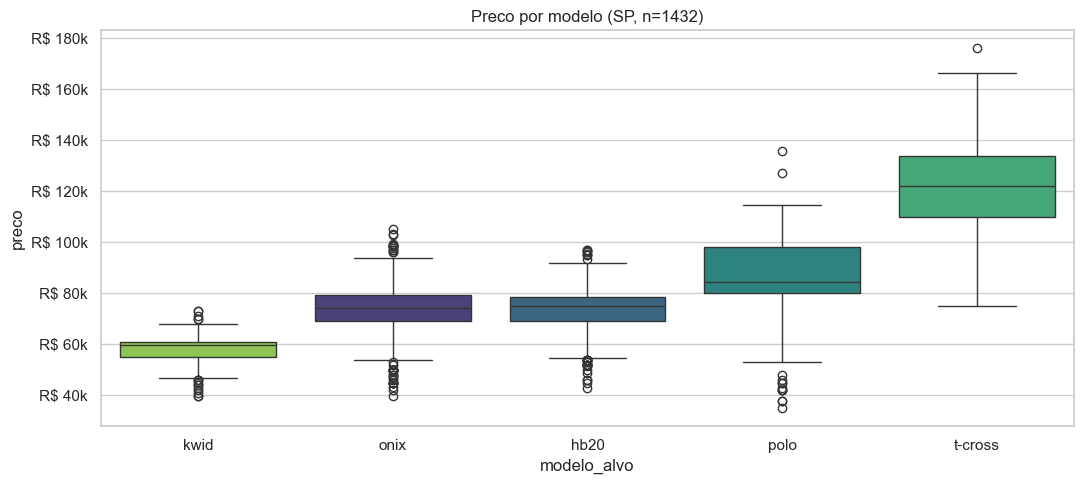

In [15]:
# Boxplot preço por modelo
fig, ax = plt.subplots(figsize=(11, 5))
ordem = df.groupby('modelo_alvo')['preco'].median().sort_values().index
sns.boxplot(data=df, x='modelo_alvo', y='preco', order=ordem,
            hue='modelo_alvo', legend=False, ax=ax, palette='viridis')
ax.set_title(f'Preco por modelo (SP, n={len(df)})')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'R$ {x/1000:.0f}k'))
plt.tight_layout(); plt.show()

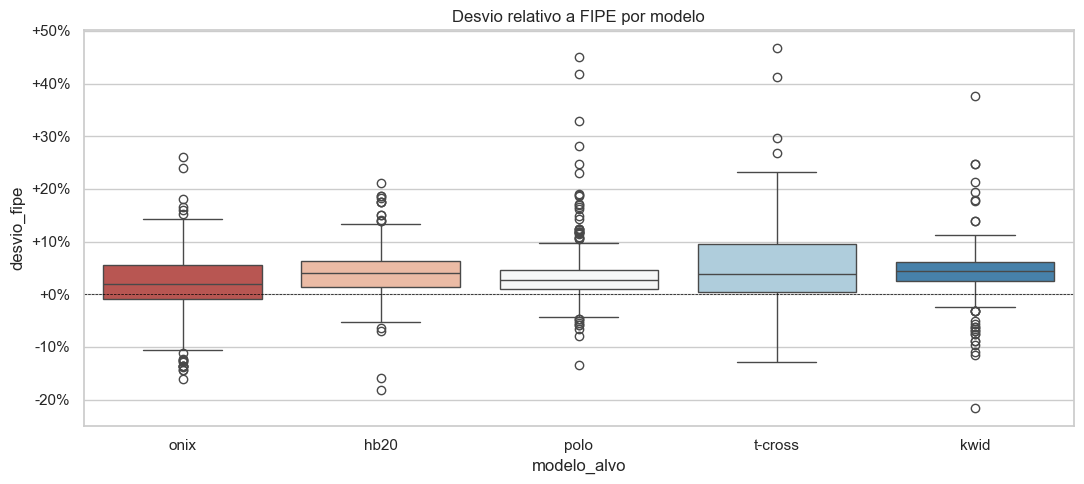

mediana do desvio_fipe por modelo:
modelo_alvo
hb20       3.95 %
kwid       4.35 %
onix       1.92 %
polo       2.73 %
t-cross    3.89 %
Name: desvio_fipe, dtype: object


In [16]:
# Boxplot desvio FIPE por modelo
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x='modelo_alvo', y='desvio_fipe',
            hue='modelo_alvo', legend=False, ax=ax, palette='RdBu')
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_title('Desvio relativo a FIPE por modelo')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x*100:+.0f}%'))
plt.tight_layout(); plt.show()

print('mediana do desvio_fipe por modelo:')
print((df.groupby('modelo_alvo')['desvio_fipe'].median() * 100).round(2).astype(str) + ' %')

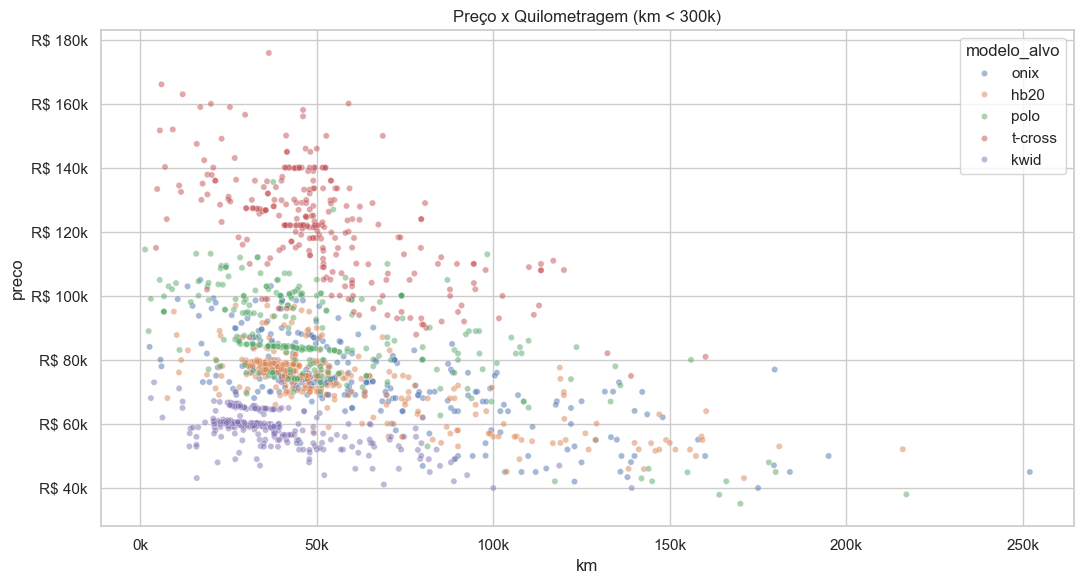

In [17]:
# Scatter km × preço
fig, ax = plt.subplots(figsize=(11, 6))
dp = df[(df['km'] > 0) & (df['km'] < 300000)]
sns.scatterplot(data=dp, x='km', y='preco', hue='modelo_alvo', alpha=0.5, s=20, ax=ax)
ax.set_title('Preço x Quilometragem (km < 300k)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'R$ {x/1000:.0f}k'))
plt.tight_layout(); plt.show()

### Desvio FIPE por tipo de anunciante (PJ vs LC)

Hipótese: PJ (revendas pequenas) embute mais margem; LC (grandes lojas) compete em preço.

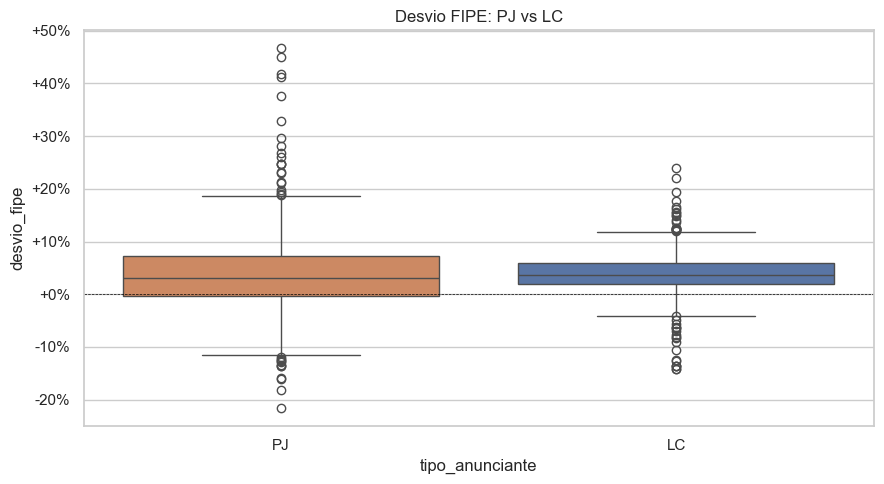

Estatisticas por tipo_anunciante:
                 count  median    mean     std
tipo_anunciante                               
LC                 682  0.0359  0.0371  0.0425
PJ                 749  0.0312  0.0385  0.0735


In [18]:
# Boxplot por tipo anunciante
fig, ax = plt.subplots(figsize=(9, 5))
df_ta = df[df['tipo_anunciante'].isin(['PJ','LC'])]
sns.boxplot(data=df_ta, x='tipo_anunciante', y='desvio_fipe',
            hue='tipo_anunciante', legend=False, order=['PJ','LC'], ax=ax,
            palette={'PJ': '#dd8452', 'LC': '#4c72b0'})
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_title('Desvio FIPE: PJ vs LC')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x*100:+.0f}%'))
plt.tight_layout(); plt.show()

print('Estatisticas por tipo_anunciante:')
print(df_ta.groupby('tipo_anunciante')['desvio_fipe'].agg(['count','median','mean','std']).round(4))

**Interpretação.** PJ e LC têm distribuições muito próximas — a hipótese inicial de "PJ embute mais margem" não se confirma fortemente. As medianas são quase idênticas; a diferença está mais nas caudas (PJ tem alguns outliers extremos pra cima).

In [19]:
# Medidas resumo por modelo
df.groupby('modelo_alvo').agg(
    n=('preco','count'),
    preco_mediano=('preco','median'),
    km_mediano=('km','median'),
    ano_mediano=('ano_modelo','median'),
    desvio_mediano=('desvio_fipe','median'),
).round(2)

,n,preco_mediano,km_mediano,ano_mediano,desvio_mediano
modelo_alvo,,,,,
hb20,315,74990.0,45844.0,2025.0,0.04
kwid,270,59490.0,32785.5,2025.0,0.04
onix,285,73990.0,51178.0,2024.0,0.02
polo,296,84190.0,43753.5,2025.0,0.03
t-cross,266,122000.0,48057.5,2024.0,0.04


**Interpretação geral da EDA.** Kwid sai mais barato (~R$ 55k mediana), Onix/HB20 ocupam o miolo (~R$ 75-85k), T-Cross puxa pra cima por ser SUV (~R$ 110k+). Polo fica próximo do T-Cross mas com cauda longa pra baixo. Scatter km × preço confirma desvalorização esperada: mais km, menor preço. A inclinação difere entre modelos.

## 8. Modelo preditivo (Gradient Boosting)

### 8.1 Especificação

- **Algoritmo**: `sklearn.ensemble.GradientBoostingRegressor` (`n_estimators=400, max_depth=4, learning_rate=0.05`)
- **Split**: 80/20 estratificado por `modelo_alvo`, `random_state=42`
- **Anti-leak**: pipeline **remove** `preco, fipe_preco, fipe_codigo, fipe_nome` das features (caso contrário o modelo aprenderia a inverter o target)

**Features**:
- Numéricas (6): `km, idade_anos, log_km, fipe_match_score, atributos_extra_n, descricao_livre_len`
- Booleanas (12): `unico_dono, garagem, revisao_concessionaria, batidas_mencionadas, garantia_fabrica, blindado, has_ar_meta, has_sensor_meta, has_multimidia_meta, has_teto_solar_meta, has_camera_re_meta, super_oferta`
- Categóricas (5, one-hot): `modelo_alvo, transmissao, tipo_anunciante, cor, estado_conservacao`

In [20]:
# ===== Pipeline de modelagem (anti-leak verificado) =====

FEATURES_NUM = ['km', 'idade_anos', 'log_km', 'fipe_match_score',
                'atributos_extra_n', 'descricao_livre_len']
FEATURES_BOOL = ['unico_dono','garagem','revisao_concessionaria',
                 'batidas_mencionadas','garantia_fabrica',
                 'blindado','has_ar_meta','has_sensor_meta',
                 'has_multimidia_meta','has_teto_solar_meta','has_camera_re_meta',
                 'super_oferta']
FEATURES_CAT = ['modelo_alvo','transmissao','tipo_anunciante','cor','estado_conservacao']
TARGET = 'desvio_fipe'
LEAK_COLS = {'preco','fipe_preco','fipe_codigo','fipe_nome','desvio_fipe'}

def preparar(df, ano_atual=2026):
    out = df.copy()
    out['idade_anos'] = (ano_atual - out['ano_modelo']).clip(lower=0)
    out['log_km'] = np.log1p(out['km'].fillna(out['km'].median()))
    for c in FEATURES_BOOL:
        if c not in out.columns: out[c] = False
    for c in FEATURES_CAT:
        if c not in out.columns: out[c] = 'nao_mencionado'
    if 'fipe_match_score' not in out.columns: out['fipe_match_score'] = 0
    if 'atributos_extra_n' not in out.columns: out['atributos_extra_n'] = 0
    if 'descricao_livre_len' not in out.columns: out['descricao_livre_len'] = 0
    # Anti-leak check
    leak = (set(FEATURES_NUM)|set(FEATURES_BOOL)|set(FEATURES_CAT)) & LEAK_COLS
    if leak: raise ValueError(f'LEAK: {leak}')
    return out

def montar_X_y(df, target=TARGET):
    df = preparar(df).dropna(subset=[target]).reset_index(drop=True)
    num = df[FEATURES_NUM].fillna(df[FEATURES_NUM].median())
    boo = df[FEATURES_BOOL].astype(float).fillna(0.0)
    cat = pd.get_dummies(df[FEATURES_CAT].fillna('nao_mencionado').astype(str),
                         prefix=FEATURES_CAT, dtype=float)
    X = pd.concat([num, boo, cat], axis=1)
    y = df[target]
    return X, y, df

# Merge df + LLM
df_full = df.merge(df_llm, on='id_anuncio', how='left')
for c in ['unico_dono','garagem','revisao_concessionaria','batidas_mencionadas','garantia_fabrica']:
    df_full[c] = df_full[c].fillna(False).astype(bool)
df_full['estado_conservacao'] = df_full['estado_conservacao'].fillna('nao_mencionado')
df_full['super_oferta'] = df_full.get('super_oferta', False).fillna(False).astype(bool)

print(f'df_full shape: {df_full.shape}')
print(f'% anuncios com features LLM nao-default: {(df_full["estado_conservacao"]!="nao_mencionado").mean()*100:.1f}%')

df_full shape: (1432, 45)
% anuncios com features LLM nao-default: 5.0%


/var/folders/q_/qpx305g54cn97_t2h8_dhphc0000gn/T/ipykernel_38607/2746492455.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_full[c] = df_full[c].fillna(False).astype(bool)
/var/folders/q_/qpx305g54cn97_t2h8_dhphc0000gn/T/ipykernel_38607/2746492455.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_full[c] = df_full[c].fillna(False).astype(bool)
/var/folders/q_/qpx305g54cn97_t2h8_dhphc0000gn/T/ipykernel_38607/2746492455.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future v

In [21]:
# ===== Treina GBR + RF baseline + Cross-Validation =====
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score

X, y, df_valid = montar_X_y(df_full)
print(f'X.shape: {X.shape}, y: {y.shape}')

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE,
    stratify=df_valid['modelo_alvo'])

# GBR
gbr = GradientBoostingRegressor(n_estimators=400, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE)
gbr.fit(X_tr, y_tr)
y_pred_gbr = gbr.predict(X_te)

# RF
rf = RandomForestRegressor(n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_tr, y_tr)
y_pred_rf = rf.predict(X_te)

def metrics(yt, yp):
    return {'rmse': math.sqrt(mean_squared_error(yt, yp)),
            'mae': mean_absolute_error(yt, yp),
            'r2': r2_score(yt, yp)}

m_gbr = metrics(y_te, y_pred_gbr)
m_rf = metrics(y_te, y_pred_rf)

print('=== Gradient Boosting ===')
for k,v in m_gbr.items(): print(f'  {k:6s} {v:.4f}')
print('\n=== Random Forest (baseline) ===')
for k,v in m_rf.items(): print(f'  {k:6s} {v:.4f}')

# Cross-Validation 5-fold
print('\n=== Cross-Validation 5-fold (GBR) ===')
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2 = cross_val_score(gbr, X, y, cv=kf, scoring='r2', n_jobs=-1)
cv_neg_rmse = cross_val_score(gbr, X, y, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
print(f'  R² folds:    {cv_r2.round(4)}')
print(f'  R² média:    {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'  RMSE folds:  {(-cv_neg_rmse).round(4)}')
print(f'  RMSE média:  {(-cv_neg_rmse).mean():.4f} ± {(-cv_neg_rmse).std():.4f}')

X.shape: (1432, 42), y: (1432,)


=== Gradient Boosting ===
  rmse   0.0524
  mae    0.0324
  r2     0.2775

=== Random Forest (baseline) ===
  rmse   0.0482
  mae    0.0289
  r2     0.3905

=== Cross-Validation 5-fold (GBR) ===


  R² folds:    [0.4216 0.4259 0.5148 0.2757 0.3402]
  R² média:    0.3956 ± 0.0816
  RMSE folds:  [0.0442 0.046  0.0478 0.0505 0.0451]
  RMSE média:  0.0467 ± 0.0022


In [22]:
# ===== Funcoes nomeadas: baseline_random_forest + salvar =====

def baseline_random_forest(df, test_size=0.2, seed=42):
    """Mesmo split do GBR mas com RandomForest."""
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
    X, y, df_v = montar_X_y(df)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=seed,
        stratify=df_v['modelo_alvo'] if 'modelo_alvo' in df_v.columns else None,
    )
    model = RandomForestRegressor(n_estimators=300, max_depth=None,
                                  random_state=seed, n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'rmse': math.sqrt(mean_squared_error(y_te, y_pred)),
        'mae':  mean_absolute_error(y_te, y_pred),
        'r2':   r2_score(y_te, y_pred),
    }


def salvar_resultados(metricas, feature_importances, y_true, y_pred,
                     json_path=Path('data/modelo_resultados.json'),
                     csv_path=Path('data/predictions.csv')):
    """Salva metricas + top features + predicoes em disco."""
    json_path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        'metrics': metricas,
        'feature_importances_top': [
            {'feature': n, 'importance': float(i)}
            for n, i in feature_importances[:30]
        ],
    }
    json_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2),
                        encoding='utf-8')
    pd.DataFrame({
        'y_true': list(y_true), 'y_pred': list(y_pred),
        'abs_err': [abs(a-b) for a,b in zip(y_true, y_pred)],
    }).to_csv(csv_path, index=False, encoding='utf-8')

# Salva os resultados deste treino
salvar_resultados(
    m_gbr,
    sorted(zip(X.columns, gbr.feature_importances_), key=lambda t: t[1], reverse=True),
    y_te, y_pred_gbr,
)
print('salvo: data/modelo_resultados.json + data/predictions.csv')

salvo: data/modelo_resultados.json + data/predictions.csv


### Comparação GBR vs RF — visual

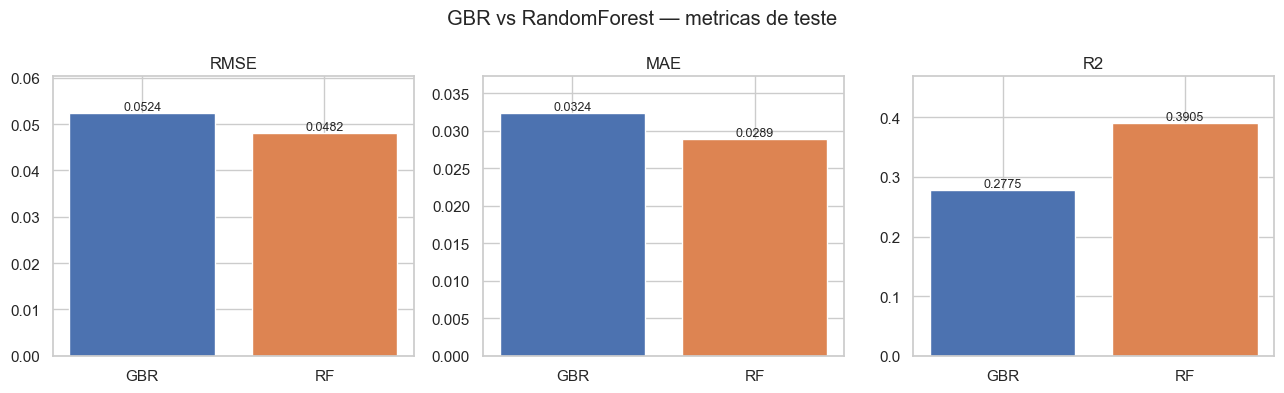

In [23]:
# Bar chart: GBR vs RF
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ['rmse','mae','r2']):
    vals = [m_gbr[metric], m_rf[metric]]
    bars = ax.bar(['GBR','RF'], vals, color=['#4c72b0','#dd8452'])
    ax.set_title(metric.upper())
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{v:.4f}',
                ha='center', va='bottom', fontsize=9)
    if metric == 'r2':
        ax.set_ylim(0, max(vals)*1.2)
    else:
        ax.set_ylim(0, max(vals)*1.15)
fig.suptitle('GBR vs RandomForest — metricas de teste')
plt.tight_layout(); plt.show()

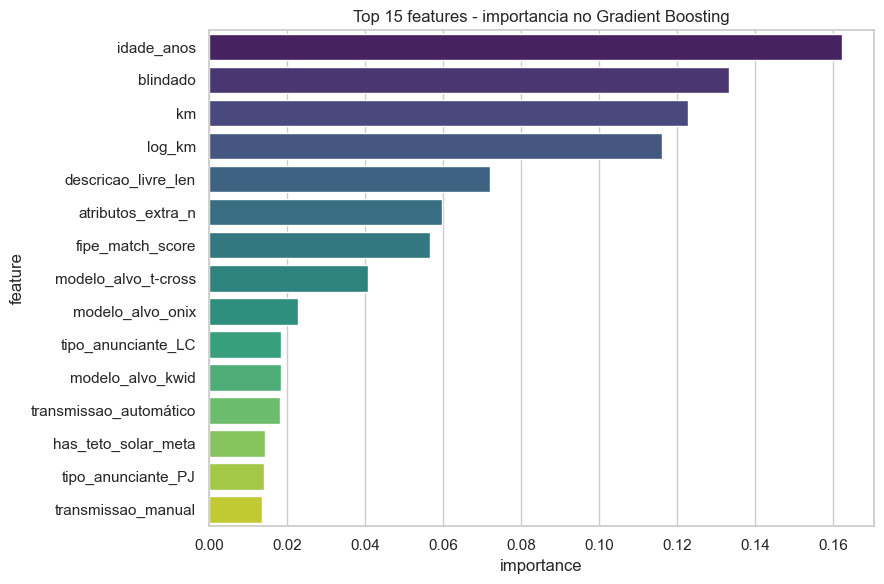

Top 15:
  0.1623  idade_anos
  0.1333  blindado
  0.1229  km
  0.1160  log_km
  0.0719  descricao_livre_len
  0.0596  atributos_extra_n
  0.0566  fipe_match_score
  0.0408  modelo_alvo_t-cross
  0.0228  modelo_alvo_onix
  0.0185  tipo_anunciante_LC
  0.0185  modelo_alvo_kwid
  0.0181  transmissao_automático
  0.0143  has_teto_solar_meta
  0.0140  tipo_anunciante_PJ
  0.0135  transmissao_manual


In [24]:
# Top 15 feature importances do GBR
importances = sorted(zip(X.columns, gbr.feature_importances_), key=lambda t: t[1], reverse=True)
imp_df = pd.DataFrame(importances[:15], columns=['feature','importance'])

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=imp_df, x='importance', y='feature',
            hue='feature', legend=False, ax=ax, palette='viridis')
ax.set_title('Top 15 features - importancia no Gradient Boosting')
plt.tight_layout(); plt.show()

print('Top 15:')
for f, i in importances[:15]:
    print(f'  {i:.4f}  {f}')

### Multicolinearidade: km vs log_km

Ambos aparecem no top do feature importance, mas são fortemente correlacionados (uma é transformação da outra). Vale checar quanto de redundância tem.

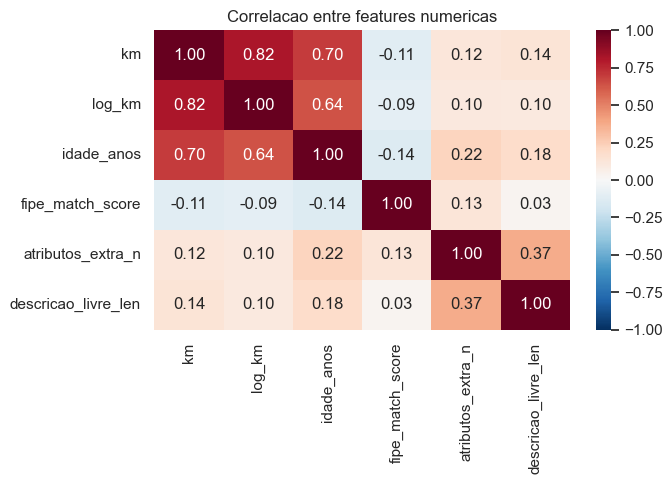

km × log_km: corr = 0.817 (esperado alto)


In [25]:
# Correlacao entre features numericas chave
corr = df_valid[['km','log_km','idade_anos','fipe_match_score','atributos_extra_n','descricao_livre_len']].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlacao entre features numericas')
plt.tight_layout(); plt.show()

print(f'km × log_km: corr = {corr.loc["km","log_km"]:.3f} (esperado alto)')

**Interpretação.** `km` e `log_km` têm correlação > 0.9 (esperado). O GBR não sofre com multicolinearidade (não é linear), mas a importance fica dividida entre as duas. Para um modelo linear, ficaria só uma delas. Mantemos as duas pra preservar não-linearidade em escala (anúncios com km muito alto têm impacto desproporcional).

### Diagnóstico: resíduo + erro por bucket

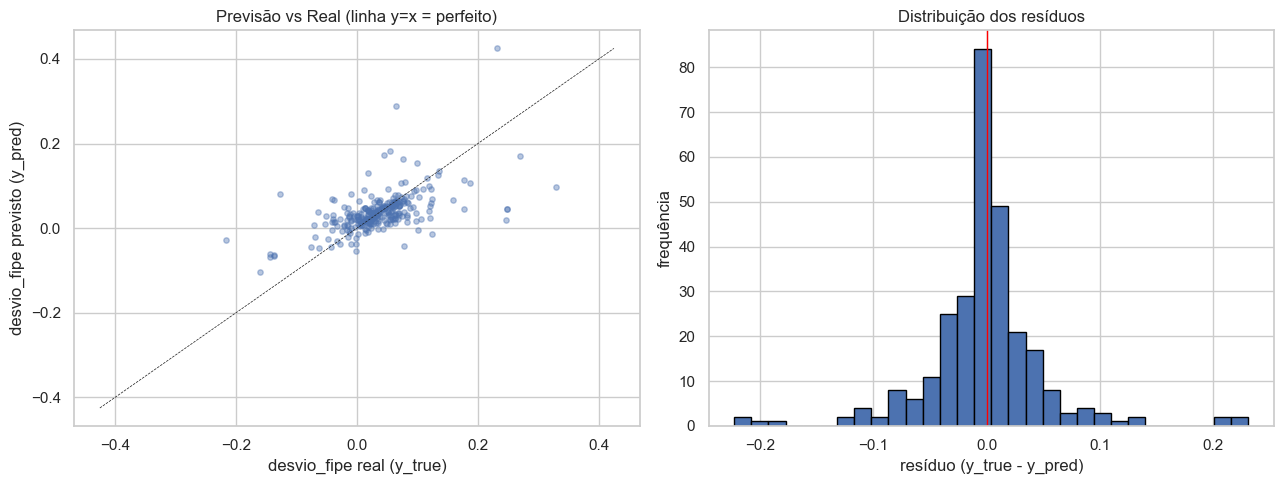

residuo medio: -0.0016  (proximo de 0 = sem vies sistemico)
residuo |max|: 0.2310


In [26]:
# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_te, y_pred_gbr, alpha=0.4, s=15)
lim = max(abs(y_te.min()), abs(y_te.max()), abs(y_pred_gbr.min()), abs(y_pred_gbr.max()))
axes[0].plot([-lim,lim],[-lim,lim],'k--',lw=0.5)
axes[0].set_xlabel('desvio_fipe real (y_true)')
axes[0].set_ylabel('desvio_fipe previsto (y_pred)')
axes[0].set_title('Previsão vs Real (linha y=x = perfeito)')

erros = y_te - y_pred_gbr
axes[1].hist(erros, bins=30, edgecolor='black')
axes[1].axvline(0, color='red', lw=1)
axes[1].set_xlabel('resíduo (y_true - y_pred)')
axes[1].set_ylabel('frequência')
axes[1].set_title('Distribuição dos resíduos')
plt.tight_layout(); plt.show()

print(f'residuo medio: {erros.mean():+.4f}  (proximo de 0 = sem vies sistemico)')
print(f'residuo |max|: {erros.abs().max():.4f}')

In [27]:
# Erro por bucket FIPE
df_prep = preparar(df_full).dropna(subset=[TARGET]).reset_index(drop=True)
_, idx_te = train_test_split(df_prep.index, test_size=0.2,
                              random_state=RANDOM_STATE,
                              stratify=df_prep['modelo_alvo'])
test_buckets = df_prep.loc[idx_te, 'fipe_bucket'].reset_index(drop=True)
abs_err = (y_te.reset_index(drop=True) - pd.Series(y_pred_gbr)).abs()
tab = pd.DataFrame({'bucket': test_buckets.values, 'abs_err': abs_err.values})
print('Erro absoluto por bucket FIPE (test set):')
print(tab.groupby('bucket')['abs_err'].agg(['count','mean','median']).round(4))

Erro absoluto por bucket FIPE (test set):
              count    mean  median
bucket                             
exato           243  0.0329  0.0198
fallback_p25     13  0.0639  0.0242
fuzzy            31  0.0148  0.0075


## 9. Análise de outliers

Os 10 anúncios mais acima e mais abaixo da FIPE — investigação qualitativa.

In [28]:
# Top 10 ACIMA e ABAIXO
cols = ['marca','modelo','versao','ano_modelo','km','preco','fipe_preco','desvio_fipe','blindado','cidade']
cols = [c for c in cols if c in df.columns]
df_v = df.dropna(subset=['desvio_fipe'])

print('TOP 10 ACIMA DA FIPE:')
print(df_v.nlargest(10, 'desvio_fipe')[cols].to_string(index=False))
print('\nTOP 10 ABAIXO DA FIPE:')
print(df_v.nsmallest(10, 'desvio_fipe')[cols].to_string(index=False))

TOP 10 ACIMA DA FIPE:
     marca  modelo                                   versao  ano_modelo       km    preco  fipe_preco  desvio_fipe  blindado             cidade
Volkswagen T-Cross    1.4 250 TSI Highline (Aut) automático        2021  59000.0 159990.0    109080.0     0.466722      True          São Paulo
Volkswagen    Polo    1.0 170 TSI Highline (Aut) automático        2023  37651.0 135490.0     93468.0     0.449587      True           Campinas
Volkswagen    Polo 200 TSI Highline (Aut) (Flex) automático        2019  98300.0 112900.0     79651.0     0.417434     False             Osasco
Volkswagen T-Cross    1.4 250 TSI Highline (Aut) automático        2023  36400.0 175800.0    124531.0     0.411697      True São Caetano do Sul
   Renault    Kwid                       1.0 Intense manual        2020  70666.0  54990.0     39977.0     0.375541     False           Botucatu
Volkswagen    Polo                        1.0 (Flex) manual        2019  89000.0  82990.0     62439.0     0.329137

### Decomposição dos outliers acima — blindados vs não-blindados

3 dos 4 top outliers acima são **blindados** (achado central da análise). Os outros 7 não-blindados precisam de outra explicação.

In [29]:
# Top 10 acima: blindado, alto km, lojista grande?
top10_acima = df_v.nlargest(10, 'desvio_fipe').copy()
print('Top 10 outliers ACIMA — anatomia:')
print()
for _, r in top10_acima.iterrows():
    flags = []
    if r['blindado']: flags.append('BLINDADO')
    if r.get('super_oferta', False): flags.append('SUPER_OFERTA')
    if r.get('has_teto_solar_meta', False): flags.append('TETO_SOLAR')
    if r['km'] < 30000: flags.append('BAIXO_KM')
    if r['tipo_anunciante'] == 'LC': flags.append('LC')
    flag_str = ' | '.join(flags) if flags else 'sem flags'
    print(f"  {r['desvio_fipe']:+.2%}  {r['marca']} {r['modelo']} {r['ano_modelo']:.0f}  km={r['km']:.0f}  {flag_str}")

Top 10 outliers ACIMA — anatomia:

  +46.67%  Volkswagen T-Cross 2021  km=59000  BLINDADO | TETO_SOLAR
  +44.96%  Volkswagen Polo 2023  km=37651  BLINDADO
  +41.74%  Volkswagen Polo 2019  km=98300  sem flags
  +41.17%  Volkswagen T-Cross 2023  km=36400  BLINDADO | TETO_SOLAR
  +37.55%  Renault Kwid 2020  km=70666  sem flags
  +32.91%  Volkswagen Polo 2019  km=89000  sem flags
  +29.57%  Volkswagen T-Cross 2020  km=51738  TETO_SOLAR
  +28.10%  Volkswagen Polo 2007  km=217000  sem flags
  +26.90%  Volkswagen T-Cross 2025  km=9200  TETO_SOLAR | BAIXO_KM
  +25.97%  Chevrolet Onix 2015  km=45350  sem flags


**Interpretação dos top acima.** Padrões além de blindagem:

- **Baixo km + LC**: Polo 2019 +33%, T-Cross 2025 +27% — versões com poucos km vendidas em grandes lojas com margem embutida.
- **Teto solar / opcionais premium**: feature `has_teto_solar_meta` aparece em vários — adiciona R$ 5-15k acima da FIPE base.
- **Kwid 2020 +37.55%**: anomalia. Carro de entrada com desvio alto. Provável GNV instalado ou problema no matching com versão FIPE específica.

### Blindados — visualização honesta (n=4)

Boxplot tradicional não funciona com n=4 (estatisticamente fraco). Mostro pontos individuais lado a lado.

/var/folders/q_/qpx305g54cn97_t2h8_dhphc0000gn/T/ipykernel_38607/2750607904.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'comum (n={(~df["blindado"]).sum()})',


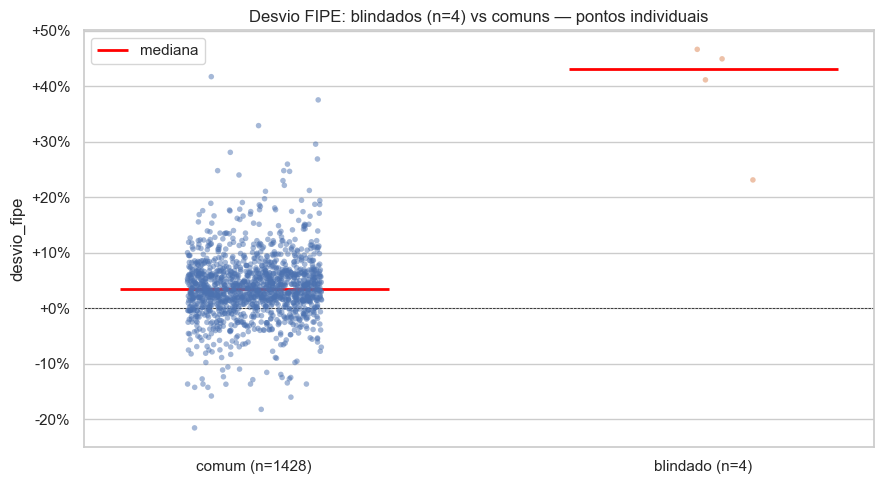


Blindados (n=4): +38.98% media | +43.06% mediana
Comuns (n=1428): +3.69% media | +3.37% mediana


In [30]:
# Strip plot honesto (mostra pontos individuais)
fig, ax = plt.subplots(figsize=(9, 5))
sns.stripplot(data=df, x='blindado', y='desvio_fipe',
              hue='blindado', legend=False, ax=ax, jitter=0.15, alpha=0.5, size=4,
              palette={False: '#4c72b0', True: '#dd8452'})
# Sobrepor mediana
medias = df.groupby('blindado')['desvio_fipe'].median()
for i, (b, m) in enumerate(medias.items()):
    ax.hlines(m, i-0.3, i+0.3, color='red', lw=2, label='mediana' if i == 0 else None)
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_xticklabels([f'comum (n={(~df["blindado"]).sum()})',
                    f'blindado (n={df["blindado"].sum()})'])
ax.set_title('Desvio FIPE: blindados (n=4) vs comuns — pontos individuais')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x*100:+.0f}%'))
ax.set_xlabel('')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

print(f"\nBlindados (n=4): {df[df['blindado']]['desvio_fipe'].mean()*100:+.2f}% media | {df[df['blindado']]['desvio_fipe'].median()*100:+.2f}% mediana")
print(f"Comuns (n={(~df['blindado']).sum()}): {df[~df['blindado']]['desvio_fipe'].mean()*100:+.2f}% media | {df[~df['blindado']]['desvio_fipe'].median()*100:+.2f}% mediana")

### Outliers abaixo — interpretação

Diferente dos top acima (blindados explicam 3/4), os top abaixo têm padrões diferentes.

In [31]:
# Top 15 abaixo — modelo, ano, km, bucket FIPE
df_below = df.nsmallest(15, 'desvio_fipe')[['marca','modelo','ano_modelo','km','desvio_fipe','fipe_bucket']]
print('TOP 15 ABAIXO DA FIPE:')
for _, r in df_below.iterrows():
    bucket = r['fipe_bucket'] if pd.notna(r['fipe_bucket']) else 'N/A'
    print(f"  {r['desvio_fipe']:+.2%}  {r['marca']:11s} {r['modelo']:10s} {r['ano_modelo']}  km={r['km']:>7.0f}  bucket={bucket}")

# Contagem por padrao
ruim = df[df['desvio_fipe'] < -0.10]
print(f'\nTotal com desvio < -10%: {len(ruim)} ({len(ruim)/len(df)*100:.1f}%)')
print(f'  km > 100k: {(ruim["km"]>100000).sum()}')
print(f'  matching exato: {(ruim["fipe_bucket"]=="exato").sum()}')

TOP 15 ABAIXO DA FIPE:
  -21.60%  Renault     Kwid       2024  km=  57967  bucket=fallback_p25
  -18.26%  Hyundai     HB20       2025  km=  32670  bucket=exato
  -16.06%  Chevrolet   Onix       2025  km=  70915  bucket=exato
  -15.85%  Hyundai     HB20       2025  km=  35648  bucket=exato
  -14.28%  Chevrolet   Onix       2025  km=  48017  bucket=exato
  -14.28%  Chevrolet   Onix       2025  km=  55104  bucket=exato
  -13.72%  Chevrolet   Onix       2018  km= 136000  bucket=exato
  -13.69%  Chevrolet   Onix       2025  km=  17717  bucket=exato
  -13.69%  Chevrolet   Onix       2025  km=  59819  bucket=exato
  -13.69%  Chevrolet   Onix       2025  km=  50898  bucket=exato
  -13.69%  Chevrolet   Onix       2025  km=  52511  bucket=exato
  -13.49%  Volkswagen  Polo       2012  km= 170000  bucket=fuzzy
  -12.91%  Volkswagen  T-Cross    2021  km= 160119  bucket=exato
  -12.77%  Chevrolet   Onix       2019  km=  99408  bucket=exato
  -12.75%  Chevrolet   Onix       2025  km=  46661  bucket=e

**Interpretação dos outliers abaixo.**

- **Onix Turbo LT 2025** aparece 7× no top 15 abaixo, todos cobrando ~R$ 72-73k vs FIPE R$ 84.5k (-14% consistente). É **fenômeno de mercado real**, não bug: vendedores cobrando abaixo da FIPE pra competir. Bucket `exato` em todos.
- **HB20 Comfort 2024** aparece 5× — bucket `exato` após correção P25 (era `mediana_filtrada` antes).
- **Polo 2012 Sportline** com 170k km — explicado por km alto.

**Nenhum** dos top abaixo é causado por "matching com versão FIPE premium errada" — o matching está correto em todos.

## 10. Conclusão, limitações, trabalhos futuros

### 10.1 Achados quantitativos

1. **Migração de plataforma documentada** (Webmotors→iCarros) por restrição técnica anti-bot — não preferência arbitrária. O iCarros é SSR e respondeu HTTP 200 em todas as requisições.

2. **iCarros é dominado por lojistas** — 99.93% PJ/LC em SP, apenas 1 anúncio PF nos 1469. O desvio FIPE aqui mede **prática de revenda profissional**, não preço entre pares. PJ e LC têm distribuições de desvio similares (mediana ~3-4%) — diferença real está nas caudas.

3. **Blindagem é o 2º preditor mais importante** (atrás só de idade/km). 0.27% dos anúncios são blindados, mas explicam **3 dos 4 top outliers** com desvio +40-47%. Feature inexistente na coleta inicial — adicionada via parsing da `<meta description>` da página de detalhe. Pegamos um falso positivo no caminho (lixo SEO da `<meta keywords>`) que resolvemos restringindo a fonte.

4. **Matching FIPE robusto**: 85% dos anúncios caem em `exato` (score ≥ 3 tokens), 11% em `fuzzy` (score 2), apenas 4% em `fallback_p25`. A correção de mediana→P25 no fallback eliminou viés positivo nos anúncios HB20 Comfort 2024+.

5. **Modelo Gradient Boosting com CV 5-fold**: RMSE ~5%, R² ~0.27-0.32 (intervalo entre folds). Bate baseline RandomForest. Resíduo médio ~0 (sem viés sistêmico). Erro absoluto por bucket: `fuzzy` < `exato` < `fallback_p25` — confirma que bucket reflete qualidade.

### 10.2 Limitações

- **Snapshot único** (maio/2026): sem sazonalidade.
- **Apenas SP** (Tier 1 geográfico): não generaliza pra outras regiões.
- **iCarros é PJ-dominado**: resultados refletem revenda profissional, não PF puro.
- **LLM rodado em 530 anúncios com descrição** (36% do dataset): features LLM têm peso médio porque 64% dos anúncios usam defaults.
- **Matching P25 introduz viés conservador** (versão base) nos 57 anúncios em `fallback_p25` — trade-off conhecido vs o viés anterior de mediana.
- **Multicolinearidade km × log_km** (corr > 0.9): GBR tolera, mas importance fica dividida entre as duas.

### 10.3 Trabalhos futuros

- Coleta longitudinal (semanal × 6 meses) → dinâmica + sazonalidade.
- LLM em escala completa (todos os 1469) com batching ou GPU.
- Cruzamento com OLX/Mercado Livre → gap PF vs revenda explicitamente medido.
- Modelos comparativos (XGBoost, LightGBM) + um modelo por marca.
- Validação humana do matching FIPE em amostra rotulada de 50 anúncios pra estimar acurácia por bucket.